#AI4S IN LITIGATION

---

##0.REFERENCE

https://claude.ai/share/8b0f3607-44cc-4907-99ba-b5e694ac7179

##1.CONTEXT


---

Litigation is a discovery problem. A dispute arrives as a set of facts, a pool of
evidence, a jurisdiction, and an opposing party — and the task is to find the
combination of legal theories that maximises the probability of a favourable
outcome for the client while remaining squarely within the bounds of professional
ethics. That framing maps exactly onto the **AI for Science (AI4S)** paradigm: a
system that proposes candidate solutions, tests them against structured evidence,
learns from failures, and refines its search direction accordingly. The difference
from laboratory science is that the evidence is a case file, the validation
mechanism is a body of precedent, and the cost of a failed experiment is not
wasted reagents but wasted capital, damaged relationships, and — in the worst case
— an adverse judgment.

This notebook applies that paradigm to a specific commercial dispute: *Meridian
Analytics LLC v. Quantum Dynamics Corp.* Meridian is a software company that built
a proprietary analytics platform for Quantum under a two-year exclusive agreement.
Quantum stopped paying at month eight, claiming substandard deliverables despite
having signed off on every milestone. Two NDA-bound developers subsequently left
for Quantum, which launched a competing product four months later bearing
architectural similarities to Meridian's platform. Quantum then contacted Meridian's
prospective clients and told them — falsely — that Meridian was financially insolvent,
causing the loss of two confirmed prospects. The dispute involves a stopped payment,
what may be misappropriated trade secrets, and tortious interference. Multiple legal
theories are available. Not all of them are equally strong, equally ethical, or
equally likely to survive a stress test against adverse precedent.

The system that navigates that complexity has three components. `LitigationStrategyLoop`
runs one complete research cycle: it generates candidate legal theories via Claude,
passes them through an ethical gate that checks compliance with the Model Rules of
Professional Conduct, searches a synthetic precedent database for analogous cases,
simulates win probability and expected damages, stress-tests the best theory under
three adverse scenarios, produces a settlement versus trial analysis, and generates
a structured feedback diagnosis. `LitigationEvaluationAgent` governs multiple cycles,
accumulating failure context between rounds and deciding — via a structured Claude call
— whether to continue searching or accept the best theory found.

The third component is `AttorneyAdvisorAgent`, which simulates Diana Reyes, a Senior
Litigation Partner with twenty-eight years of commercial litigation experience.
Claude plays Diana reviewing every AI-generated recommendation before it can proceed.
She checks ethical compliance, evidence sufficiency, and alignment with client goals.
She may approve, approve with required modifications, or reject outright — and her
specific concerns and modification requirements are fed back into the next cycle's
hypothesis generation, so the loop learns from human judgment about what a
courtroom-ready strategy actually requires.

Three features distinguish this system from a simple legal research assistant. First,
the ethical gate is not optional: theories that violate Rule 3.1 (frivolous claims),
Rule 3.3 (candor to tribunal), or Rule 8.4 (dishonesty) are excluded before they
reach the simulation stage. The system cannot generate an expected-value number for
an unethical argument and present it as a legitimate option. Second, the precedent
engine anchors its probability estimates to specific prior outcomes in the synthetic
case law database, so the system's optimism about win rates is bounded by what
analogous fact patterns have actually produced. Third, the settlement versus trial
analysis forces the system to ask whether the expected value of proceeding to
judgment — net of litigation costs — actually exceeds a reasonable settlement demand,
because the most analytically compelling theory is not necessarily the right advice
if the client's economics favour resolution.

The synthetic legal universe used here is fictional. The jurisdiction, the Model
Rules characterisations, and the precedent outcomes are designed for pedagogical
clarity, not legal accuracy. Nothing in this notebook constitutes legal advice.
Diana Reyes is a simulated persona; no actual attorney-client relationship is
created. The purpose is to demonstrate how the AI4S discovery loop — propose,
test, learn, update — can be applied to professional advisory work where human
judgment, ethical obligation, and structured evidence analysis must operate together.




---

**Architecture**

```
LitigationEvaluationAgent  (governs up to 3 research cycles)
  |
  +--> LitigationStrategyLoop.run()  --> CycleResult
         |                                     |
         | generate legal theories (Claude)    |
         | ethical gate -- Model Rules check   |
         | precedent engine -- case law search |
         | simulate outcome / damages          |
         | stress test -- adverse scenarios    |
         | settlement vs trial analysis        |
         | get feedback (Claude)               |
                                               |
  +--> AttorneyAdvisorAgent.review()  <--------+
         | Claude plays Diana Reyes,
         | Senior Litigation Partner
         | APPROVE / APPROVE_WITH_MODS / REJECT
         |
  +--> LitigationEvaluationAgent decides:
         CONTINUE / STOP_SUCCESS / STOP_MAX_ROUNDS
```

| Cell | Content |
|------|---------|
| 1 | Setup |
| 2 | Synthetic legal universe (jurisdiction, rules, precedents) |
| 3 | Case facts and client profile |
| 4 | Precedent engine and outcome simulator |
| 5 | `LitigationStrategyLoop` class |
| 6 | `AttorneyAdvisorAgent` class |
| 7 | `LitigationEvaluationAgent` class |
| 8 | Orchestrator |
| 9 | Final litigation report dashboard |


---

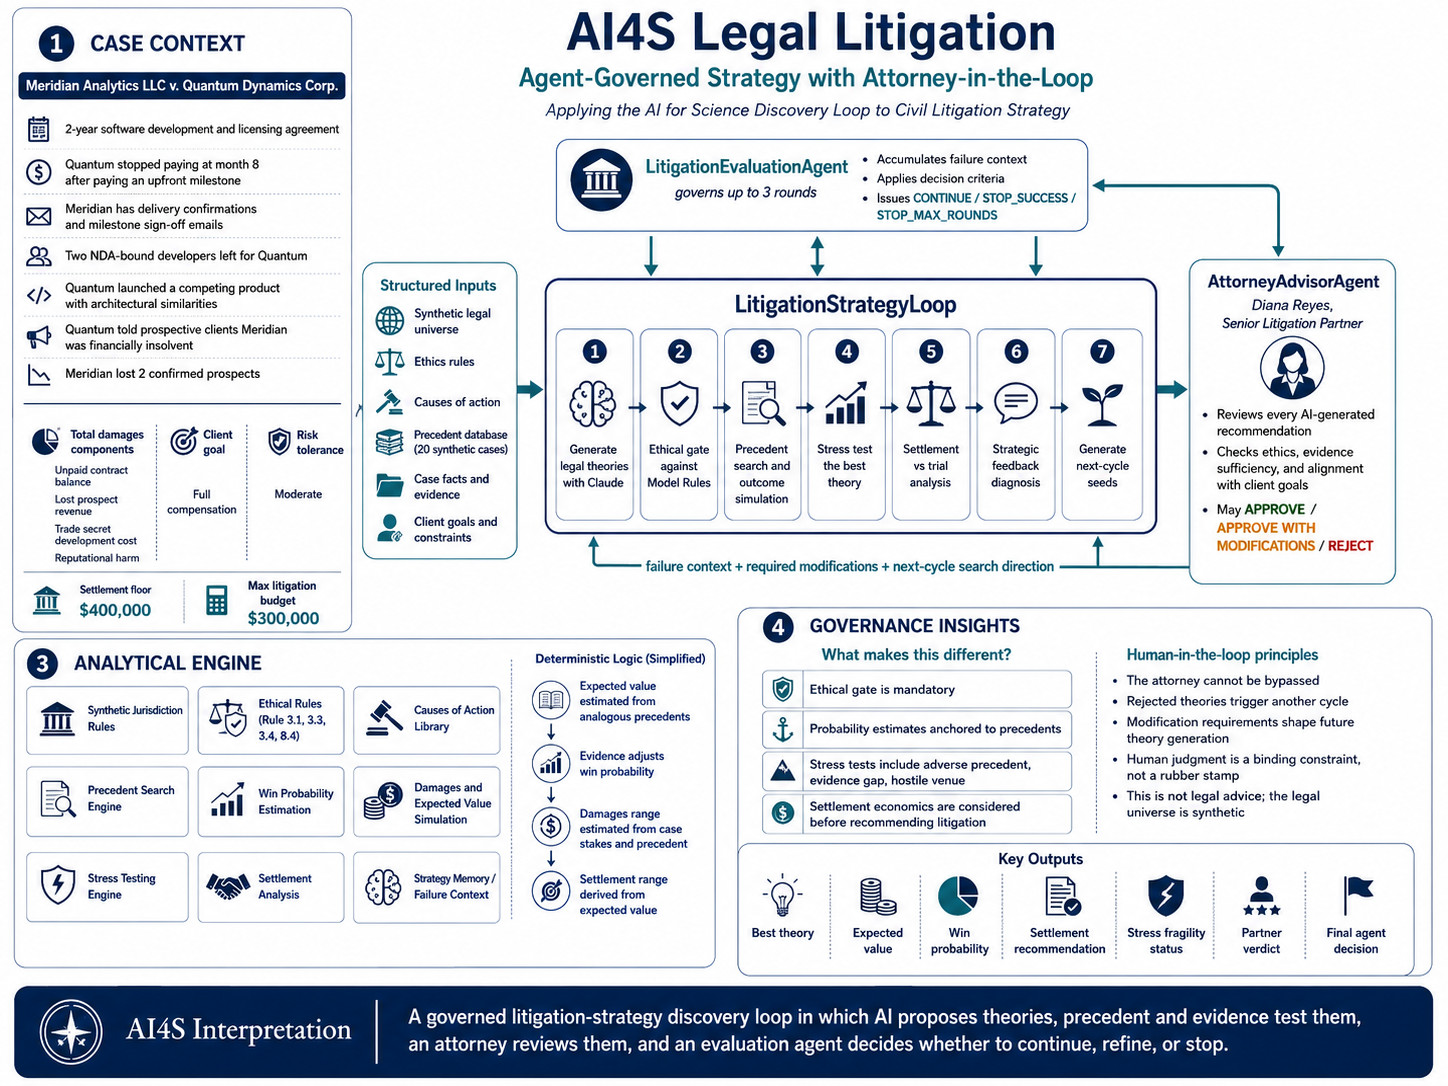

##2.CODE AND IMPLEMENTATION

In [32]:
# CELL 1  SETUP
# -----------------------------------------------------------------------
!pip install anthropic --quiet

import json, warnings
from dataclasses import dataclass, field
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from google.colab import userdata
import anthropic

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False})

API_KEY = userdata.get('ANTHROPIC_API_KEY')
CLIENT  = anthropic.Anthropic(api_key=API_KEY)
MODEL   = 'claude-haiku-4-5-20251001'

def ask_claude(system, user, max_tokens=1200):
    msg = CLIENT.messages.create(
        model=MODEL, max_tokens=max_tokens,
        system=system,
        messages=[{'role': 'user', 'content': user}]
    )
    return msg.content[0].text.strip()

def parse_json(raw):
    # Aggressively clean for markdown or other noise first
    cleaned_raw = raw.strip().replace('```json','').replace('```','').strip()

    # Attempt to parse as a complete JSON array or object
    try:
        return json.loads(cleaned_raw)
    except json.JSONDecodeError as e_direct_parse:
        pass # Fall through to more specific extractions if direct parse fails

    # Try to find and parse a JSON array within the cleaned string
    start_array_index = cleaned_raw.find('[')
    end_array_index = cleaned_raw.rfind(']')

    if start_array_index != -1 and end_array_index != -1 and start_array_index < end_array_index:
        try:
            json_str = cleaned_raw[start_array_index : end_array_index + 1]
            return json.loads(json_str)
        except json.JSONDecodeError as e_array_extract:
            pass

    # Fallback to finding and parsing a JSON object within the cleaned string
    start_object_index = cleaned_raw.find('{')
    end_object_index = cleaned_raw.rfind('}')

    if start_object_index != -1 and end_object_index != -1 and start_object_index < end_object_index:
        try:
            json_str = cleaned_raw[start_object_index : end_object_index + 1]
            return json.loads(json_str)
        except json.JSONDecodeError as e_object_extract:
            pass

    # If all attempts fail, re-raise the error with more context
    if 'e_object_extract' in locals():
        raise json.JSONDecodeError(
            f"Failed to decode JSON after multiple attempts (object extraction failed). Raw: '{raw[:100]}...', Cleaned: '{cleaned_raw[:100]}...'",
            e_object_extract.doc, e_object_extract.pos
        )
    elif 'e_array_extract' in locals():
        raise json.JSONDecodeError(
            f"Failed to decode JSON after multiple attempts (array extraction failed). Raw: '{raw[:100]}...', Cleaned: '{cleaned_raw[:100]}...'",
            e_array_extract.doc, e_array_extract.pos
        )
    else:
        raise json.JSONDecodeError(
            f"Failed to decode JSON after multiple attempts. Raw: '{raw[:100]}...', Cleaned: '{cleaned_raw[:100]}...'",
            raw, 0 # Provide raw string and default position if no specific error was caught
        )

print('Setup complete -- model:', MODEL)

Setup complete -- model: claude-haiku-4-5-20251001


In [33]:
# CELL 2  SYNTHETIC LEGAL UNIVERSE
# Jurisdiction rules, ethical obligations, causes of action,
# and a synthetic case law database of 20 precedents.
# -----------------------------------------------------------------------

JURISDICTION = {
    'name':           'Fictional State of Veridian',
    'court_system':   'Veridian Superior Court (trial) / Court of Appeals',
    'statute_of_lim': {
        'contract':       4,   # years
        'tort_general':   3,
        'fraud':          4,
        'employment':     2,
        'property':       6,
    },
    'damages_cap':    {
        'punitive_multiplier_max': 3.0,   # 3x compensatory
        'pain_suffering_cap':      500_000,
        'employment_back_pay_cap': None,   # uncapped
    },
    'discovery_rules': {
        'e_discovery_required': True,
        'depo_limit':           10,
        'interrogatory_limit':  25,
    },
    'fee_shifting': {
        'contract_prevailing_party': True,
        'employment_plaintiff_only': True,
        'tort':                      False,
    },
    'jury_trial_available': True,
    'arbitration_clause_enforceable': True,
}

# -- Model Rules of Professional Conduct (simplified) --------------------
ETHICS_RULES = {
    'rule_3_1': 'Meritorious claims only -- no frivolous arguments.',
    'rule_3_3': 'Candor to tribunal -- no false statements of fact or law.',
    'rule_1_7': 'No concurrent conflict of interest without informed consent.',
    'rule_1_6': 'Confidentiality of client information.',
    'rule_3_4': 'Fairness to opposing party -- no destruction of evidence.',
    'rule_4_1': 'Truthfulness in statements to third parties.',
    'rule_8_4': 'No conduct involving dishonesty, fraud, or misrepresentation.',
}

# -- Causes of action available ------------------------------------------
CAUSES_OF_ACTION = [
    'breach_of_contract',
    'breach_of_fiduciary_duty',
    'fraudulent_misrepresentation',
    'negligent_misrepresentation',
    'tortious_interference',
    'unjust_enrichment',
    'conversion',
    'wrongful_termination',
    'hostile_work_environment',
    'trade_secret_misappropriation',
]

# -- Synthetic precedent database: 20 cases ------------------------------
PRECEDENTS = [
    # contract disputes
    {'id':'VER-2019-0112', 'type':'breach_of_contract',
     'facts':'Software vendor failed to deliver platform per SOW. '
             'Plaintiff had emails proving missed milestones.',
     'outcome':'plaintiff_win', 'damages': 340_000, 'duration_months': 14,
     'key_factor':'documentary evidence of milestones', 'strength':'strong'},
    {'id':'VER-2020-0445', 'type':'breach_of_contract',
     'facts':'Service provider claimed force majeure for non-performance. '
             'Contract had explicit FM clause.',
     'outcome':'defendant_win', 'damages': 0, 'duration_months': 8,
     'key_factor':'express force majeure clause', 'strength':'weak_plaintiff'},
    {'id':'VER-2021-0788', 'type':'breach_of_contract',
     'facts':'Oral modification to written contract disputed. '
             'No merger clause in original agreement.',
     'outcome':'plaintiff_win', 'damages': 180_000, 'duration_months': 18,
     'key_factor':'no merger clause allowed oral modification proof', 'strength':'moderate'},
    {'id':'VER-2022-0033', 'type':'breach_of_contract',
     'facts':'Exclusive distribution agreement breached when vendor '
             'sold directly to plaintiff territory clients.',
     'outcome':'plaintiff_win', 'damages': 620_000, 'duration_months': 22,
     'key_factor':'clear exclusivity clause and lost revenue records', 'strength':'strong'},
    # fraud
    {'id':'VER-2018-0290', 'type':'fraudulent_misrepresentation',
     'facts':'Seller misrepresented company revenue in acquisition. '
             'Buyer discovered inflated figures post-close.',
     'outcome':'plaintiff_win', 'damages': 1_200_000, 'duration_months': 28,
     'key_factor':'audited records showed deliberate inflation', 'strength':'strong'},
    {'id':'VER-2021-0501', 'type':'fraudulent_misrepresentation',
     'facts':'Plaintiff alleged oral fraud but had signed integration clause. '
             'No corroborating witnesses.',
     'outcome':'defendant_win', 'damages': 0, 'duration_months': 11,
     'key_factor':'integration clause barred extrinsic fraud claim', 'strength':'weak_plaintiff'},
    {'id':'VER-2023-0099', 'type':'negligent_misrepresentation',
     'facts':'Financial advisor gave erroneous projections without basis. '
             'Client relied and suffered losses.',
     'outcome':'plaintiff_win', 'damages': 280_000, 'duration_months': 16,
     'key_factor':'no reasonable basis for projections', 'strength':'moderate'},
    # fiduciary duty
    {'id':'VER-2020-0877', 'type':'breach_of_fiduciary_duty',
     'facts':'Corporate director diverted business opportunity to self. '
             'Board minutes showed no disclosure.',
     'outcome':'plaintiff_win', 'damages': 890_000, 'duration_months': 24,
     'key_factor':'self-dealing without disclosure', 'strength':'strong'},
    {'id':'VER-2019-0655', 'type':'breach_of_fiduciary_duty',
     'facts':'Minority shareholder claimed oppression. '
             'No formal fiduciary relationship established.',
     'outcome':'defendant_win', 'damages': 0, 'duration_months': 9,
     'key_factor':'no fiduciary duty owed to minority in this structure', 'strength':'weak_plaintiff'},
    # employment
    {'id':'VER-2022-0341', 'type':'wrongful_termination',
     'facts':'Employee terminated after reporting safety violation. '
             'Timing strongly suggested retaliation.',
     'outcome':'plaintiff_win', 'damages': 420_000, 'duration_months': 19,
     'key_factor':'close temporal proximity + protected activity', 'strength':'strong'},
    {'id':'VER-2021-0190', 'type':'wrongful_termination',
     'facts':'At-will employee claimed implied contract from handbook. '
             'Handbook had explicit disclaimer.',
     'outcome':'defendant_win', 'damages': 0, 'duration_months': 7,
     'key_factor':'handbook disclaimer negated implied contract', 'strength':'weak_plaintiff'},
    {'id':'VER-2023-0204', 'type':'hostile_work_environment',
     'facts':'Systematic harassment documented over 18 months. '
             'HR complaints ignored. 4 corroborating witnesses.',
     'outcome':'plaintiff_win', 'damages': 350_000, 'duration_months': 21,
     'key_factor':'documented pattern + employer knowledge + inaction', 'strength':'strong'},
    # trade secrets
    {'id':'VER-2020-0566', 'type':'trade_secret_misappropriation',
     'facts':'Departing employee took client list and source code. '
             'NDA signed. Forensic evidence of copying.',
     'outcome':'plaintiff_win', 'damages': 750_000, 'duration_months': 17,
     'key_factor':'forensic evidence + NDA + immediate competitor use', 'strength':'strong'},
    {'id':'VER-2019-0388', 'type':'trade_secret_misappropriation',
     'facts':'Plaintiff claimed pricing model was trade secret. '
             'Model was derivable from public market data.',
     'outcome':'defendant_win', 'damages': 0, 'duration_months': 10,
     'key_factor':'information not actually secret', 'strength':'weak_plaintiff'},
    # tortious interference
    {'id':'VER-2021-0722', 'type':'tortious_interference',
     'facts':'Competitor contacted plaintiff clients with false statements '
             'about plaintiff financial instability.',
     'outcome':'plaintiff_win', 'damages': 510_000, 'duration_months': 20,
     'key_factor':'false statements + direct lost contracts documented', 'strength':'strong'},
    {'id':'VER-2022-0815', 'type':'tortious_interference',
     'facts':'Defendant competed aggressively but used only lawful means. '
             'No improper conduct established.',
     'outcome':'defendant_win', 'damages': 0, 'duration_months': 8,
     'key_factor':'competition privilege -- no improper means', 'strength':'weak_plaintiff'},
    # unjust enrichment
    {'id':'VER-2020-0133', 'type':'unjust_enrichment',
     'facts':'Plaintiff performed services under failed contract. '
             'Defendant retained benefit without paying.',
     'outcome':'plaintiff_win', 'damages': 195_000, 'duration_months': 12,
     'key_factor':'quantum meruit -- services rendered and retained', 'strength':'moderate'},
    # conversion
    {'id':'VER-2023-0441', 'type':'conversion',
     'facts':'Defendant refused to return proprietary equipment '
             'after contract termination. FMV well-documented.',
     'outcome':'plaintiff_win', 'damages': 160_000, 'duration_months': 9,
     'key_factor':'clear ownership + refusal to return', 'strength':'strong'},
    # negligence
    {'id':'VER-2019-0901', 'type':'negligent_misrepresentation',
     'facts':'Consultant overstated project ROI without methodology. '
             'Plaintiff could not prove reliance causation.',
     'outcome':'defendant_win', 'damages': 0, 'duration_months': 13,
     'key_factor':'causation link between representation and loss too attenuated', 'strength':'weak_plaintiff'},
    # mixed
    {'id':'VER-2022-0609', 'type':'breach_of_contract',
     'facts':'Joint venture dissolved without following wind-down procedure. '
             'Both parties contributed to breakdown. Mixed fault.',
     'outcome':'split_verdict', 'damages': 220_000, 'duration_months': 26,
     'key_factor':'comparative fault -- both parties in breach', 'strength':'moderate'},
]

print(f'Jurisdiction  : {JURISDICTION["name"]}')
print(f'Ethics rules  : {len(ETHICS_RULES)} Model Rules loaded')
print(f'Causes of act.: {len(CAUSES_OF_ACTION)}')
print(f'Precedents    : {len(PRECEDENTS)} cases')
wins = sum(1 for p in PRECEDENTS if p['outcome']=='plaintiff_win')
print(f'  Plaintiff wins: {wins}/{len(PRECEDENTS)}')

Jurisdiction  : Fictional State of Veridian
Ethics rules  : 7 Model Rules loaded
Causes of act.: 10
Precedents    : 20 cases
  Plaintiff wins: 12/20


In [34]:
# CELL 3  CASE FACTS AND CLIENT PROFILE
# Plaintiff: Meridian Analytics LLC v. Quantum Dynamics Corp.
# A technology services dispute with multiple legal theories available.
# -----------------------------------------------------------------------

CASE = {
    'matter_name':   'Meridian Analytics LLC v. Quantum Dynamics Corp.',
    'client':        'Meridian Analytics LLC (Plaintiff)',
    'opposing':      'Quantum Dynamics Corp. (Defendant)',

    # -- Core facts ------------------------------------------------------
    'facts': (
        'Meridian Analytics LLC entered a 2-year software development and '
        'licensing agreement with Quantum Dynamics Corp. in January 2022. '
        'Meridian agreed to build a proprietary data analytics platform for '
        'exclusive use by Quantum within the financial services sector. '
        'Quantum paid the $150,000 upfront milestone but stopped payments '
        'at month 8, claiming the deliverables were substandard. '
        'Meridian disputes this and has delivery confirmations and sign-off '
        'emails for all milestones completed. '
        'Quantum then hired two of Meridians senior developers (who had NDAs) '
        'and launched a competing product 4 months later that appears to use '
        'Meridians proprietary architecture. '
        'Quantum also contacted three of Meridians prospective clients and '
        'stated Meridian was financially insolvent -- a false claim. '
        'Meridian lost two of those three prospects as a direct result.'
    ),

    # -- Evidence inventory ----------------------------------------------
    'evidence': {
        'signed_contract':            True,
        'milestone_signoff_emails':   True,   # strong
        'payment_records':            True,
        'nda_agreements':             True,   # both developers
        'competing_product_analysis': True,   # architectural similarities
        'false_statements_witnesses': 2,      # two prospects will testify
        'developer_departure_records':True,
        'forensic_copy_evidence':     False,  # not yet obtained
        'written_defect_notice':      False,  # Quantum never sent one
        'expert_witness_available':   True,   # software architecture expert
    },

    # -- Financial stakes ------------------------------------------------
    'damages': {
        'unpaid_contract_balance':  310_000,  # months 9-24
        'lost_prospect_revenue':    480_000,  # two lost clients
        'trade_secret_dev_cost':    220_000,  # cost to rebuild stolen IP
        'reputational_harm_est':    150_000,  # conservative
        'attorneys_fees_to_date':    85_000,
    },

    # -- Client goals & constraints --------------------------------------
    'client_goals':       'full_compensation',
    'client_risk_tol':    'moderate',          # will litigate but open to settlement
    'max_litigation_budget': 300_000,
    'preferred_timeline': '18_months',
    'settlement_floor':   400_000,             # minimum acceptable settlement
    'arbitration_clause': False,               # contract did not include one

    # -- Procedural posture ----------------------------------------------
    'filing_deadline':    '4_months',          # SOL considerations
    'jurisdiction':       'Veridian Superior Court',
    'judge_assignment':   'random',
    'opposing_counsel':   'large_firm',        # well-resourced defense
}

total_damages = sum(CASE['damages'].values())
print(f'Matter        : {CASE["matter_name"]}')
print(f'Client        : {CASE["client"]}')
print(f'Total exposure: ${total_damages:,.0f}')
print(f'Settlement flr: ${CASE["settlement_floor"]:,.0f}')
print(f'Budget        : ${CASE["max_litigation_budget"]:,.0f}')
print(f'\nEvidence strength:')
for k, v in CASE['evidence'].items():
    tag = 'YES' if v is True else ('NO' if v is False else str(v))
    print(f'  {k:35s}: {tag}')

Matter        : Meridian Analytics LLC v. Quantum Dynamics Corp.
Client        : Meridian Analytics LLC (Plaintiff)
Total exposure: $1,245,000
Settlement flr: $400,000
Budget        : $300,000

Evidence strength:
  signed_contract                    : YES
  milestone_signoff_emails           : YES
  payment_records                    : YES
  nda_agreements                     : YES
  competing_product_analysis         : YES
  false_statements_witnesses         : 2
  developer_departure_records        : YES
  forensic_copy_evidence             : NO
  written_defect_notice              : NO
  expert_witness_available           : YES


In [35]:
# CELL 4  PRECEDENT ENGINE AND OUTCOME SIMULATOR
# Searches synthetic case law for analogous precedents,
# estimates win probability and damages range.
# -----------------------------------------------------------------------

@dataclass
class SimulationResult:
    theory:              str   = ''
    cause_of_action:     str   = ''
    analogous_cases:     list  = field(default_factory=list)
    win_probability:     float = 0.0
    expected_damages:    float = 0.0
    damages_low:         float = 0.0
    damages_high:        float = 0.0
    expected_value:      float = 0.0
    duration_est_months: int   = 0
    fee_shifting:        bool  = False
    settlement_range:    tuple = (0, 0)
    risk_flags:          list  = field(default_factory=list)
    notes:               list  = field(default_factory=list)


def search_precedents(cause_of_action, evidence, n=4):
    matches = [p for p in PRECEDENTS
               if p['type'] == cause_of_action]
    if not matches:
        matches = [p for p in PRECEDENTS
                   if p['strength'] == 'strong']
    return matches[:n]


def simulate_theory(theory_spec):
    coa    = theory_spec.get('cause_of_action', 'breach_of_contract')
    dmg_k  = theory_spec.get('damages_keys', [])
    addons = theory_spec.get('addon_arguments', [])

    prec   = search_precedents(coa, CASE['evidence'])
    r      = SimulationResult(theory=theory_spec.get('name',''),
                              cause_of_action=coa,
                              analogous_cases=[p['id'] for p in prec])

    # win probability from precedent outcomes
    if prec:
        wins    = sum(1 for p in prec if p['outcome'] == 'plaintiff_win')
        splits  = sum(0.5 for p in prec if p['outcome'] == 'split_verdict')
        r.win_probability = (wins + splits) / len(prec)
    else:
        r.win_probability = 0.40  # default prior

    # evidence adjustments
    ev = CASE['evidence']
    if ev.get('milestone_signoff_emails'):  r.win_probability = min(r.win_probability + 0.10, 0.95)
    if ev.get('nda_agreements'):            r.win_probability = min(r.win_probability + 0.05, 0.95)
    if ev.get('false_statements_witnesses', 0) >= 2: r.win_probability = min(r.win_probability + 0.08, 0.95)
    if not ev.get('forensic_copy_evidence'): r.win_probability = max(r.win_probability - 0.08, 0.10)
    if not ev.get('written_defect_notice'):  r.win_probability = min(r.win_probability + 0.06, 0.95)

    # damages base
    base = sum(CASE['damages'].get(k, 0) for k in dmg_k) if dmg_k else sum(CASE['damages'].values()) * 0.5
    prec_avg = np.mean([p['damages'] for p in prec]) if prec else base
    r.damages_low  = base * 0.55
    r.damages_high = min(base * 1.40,
                         JURISDICTION['damages_cap']['punitive_multiplier_max'] * base)
    r.expected_damages = (r.damages_low + r.damages_high) / 2

    # attorney fee shifting
    if coa == 'breach_of_contract' and JURISDICTION['fee_shifting']['contract_prevailing_party']:
        r.fee_shifting = True
        r.notes.append('Fee shifting available -- attorney fees recoverable if plaintiff prevails.')

    # expected value
    r.expected_value = r.win_probability * r.expected_damages

    # settlement range (typically 40-70% of expected value)
    r.settlement_range = (r.expected_value * 0.40, r.expected_value * 0.70)

    # duration estimate
    dur_avg = int(np.mean([p['duration_months'] for p in prec])) if prec else 18
    r.duration_est_months = dur_avg

    # risk flags
    if r.win_probability < 0.50:  r.risk_flags.append('Win probability below 50%.')
    if not ev.get('forensic_copy_evidence'): r.risk_flags.append('Forensic evidence not yet obtained -- critical for trade secret claim.')
    if CASE['opposing_counsel'] == 'large_firm': r.risk_flags.append('Opposing counsel is large firm -- expect aggressive discovery.')
    if r.duration_est_months > 20: r.risk_flags.append(f'Estimated {r.duration_est_months}-month timeline may exceed client budget.')

    return r


# -- Baseline simulation (no strategy) ----------------------------------
baseline_sim = simulate_theory({
    'name': 'Baseline (breach of contract only)',
    'cause_of_action': 'breach_of_contract',
    'damages_keys': ['unpaid_contract_balance'],
})
print('BASELINE SIMULATION')
print(f'  Win probability   : {baseline_sim.win_probability:.0%}')
print(f'  Expected damages  : ${baseline_sim.expected_damages:,.0f}')
print(f'  Expected value    : ${baseline_sim.expected_value:,.0f}')
print(f'  Settlement range  : ${baseline_sim.settlement_range[0]:,.0f} - ${baseline_sim.settlement_range[1]:,.0f}')
print(f'  Est. duration     : {baseline_sim.duration_est_months} months')
print(f'  Fee shifting      : {baseline_sim.fee_shifting}')
print(f'  Risk flags        : {len(baseline_sim.risk_flags)}')
for f in baseline_sim.risk_flags: print(f'    ! {f}')

BASELINE SIMULATION
  Win probability   : 93%
  Expected damages  : $302,250
  Expected value    : $281,092
  Settlement range  : $112,437 - $196,765
  Est. duration     : 15 months
  Fee shifting      : True
  Risk flags        : 2
    ! Forensic evidence not yet obtained -- critical for trade secret claim.
    ! Opposing counsel is large firm -- expect aggressive discovery.


In [36]:
# CELL 5  LitigationStrategyLoop CLASS
# One complete litigation strategy research cycle.
# -----------------------------------------------------------------------

@dataclass
class LitigationCycleResult:
    cycle_num:           int
    theories:            list  = field(default_factory=list)
    ethical_verdicts:    dict  = field(default_factory=dict)
    simulation_results:  list  = field(default_factory=list)
    best_theory:         dict  = field(default_factory=dict)
    best_sim:            object = None
    baseline_ev:         float = 0.0
    stress_results:      dict  = field(default_factory=dict)
    fragile:             bool  = True
    settlement_rec:      str   = ''
    feedback_verdict:    str   = ''
    next_seeds:          list  = field(default_factory=list)


class LitigationStrategyLoop:

    THEORY_GLOSSARY = (
        'Available causes of action:\n'
        '  breach_of_contract              standard contract breach\n'
        '  breach_of_fiduciary_duty        fiduciary relationship required\n'
        '  fraudulent_misrepresentation    intentional false statement\n'
        '  negligent_misrepresentation     careless false statement\n'
        '  tortious_interference           interference with business relations\n'
        '  unjust_enrichment               retained benefit without payment\n'
        '  conversion                      wrongful taking of property\n'
        '  wrongful_termination            employment only\n'
        '  trade_secret_misappropriation   requires NDA or improper means\n'
        'damages_keys: unpaid_contract_balance / lost_prospect_revenue / '
        'trade_secret_dev_cost / reputational_harm_est\n'
    )

    def __init__(self, cycle_num, failure_context=''):
        self.cycle_num = cycle_num
        self.failure_context = failure_context
        self.result = LitigationCycleResult(
            cycle_num=cycle_num,
            baseline_ev=baseline_sim.expected_value
        )

    # -- 1. Generate legal theories ------------------------------------
    def generate_theories(self):
        fail_block = (
            'IMPORTANT: prior theories that FAILED ethical review or stress test:\n'
            + self.failure_context
            + '\nDo NOT regenerate these. Propose stronger, more defensible theories.\n'
        ) if self.failure_context else ''

        system = (
            'You are a litigation strategy AI applying the AI4S discovery loop. '
            'Generate exactly 5 legal theories as a JSON array. '
            'Each element: name(str), '
            'primary_cause_of_action(str from the available list), '
            'secondary_causes(list of str, max 2), '
            'damages_keys(list of str from available keys), '
            'theory_description(str, 2 sentences), '
            'key_evidence_relied_on(list of str), '
            'estimated_strength(str: strong/moderate/weak), '
            'estimated_risk(str: low/medium/high). '
            'Return ONLY the JSON array, no markdown.'
        )
        case_summary = (
            f'Case: {CASE["matter_name"]}\n'
            f'Facts: {CASE["facts"]}\n\n'
            f'Evidence available: {json.dumps(CASE["evidence"], indent=2)}\n\n'
            f'Damages available: {json.dumps(CASE["damages"], indent=2)}\n\n'
            f'Client goals: {CASE["client_goals"]}\n'
            f'Risk tolerance: {CASE["client_risk_tol"]}\n'
            f'Settlement floor: ${CASE["settlement_floor"]:,}\n\n'
            f'Baseline expected value (contract only): ${baseline_sim.expected_value:,.0f}\n\n'
        )
        user = (
            fail_block
            + case_summary
            + f'Available theories:\n{self.THEORY_GLOSSARY}\n'
            + 'Generate 5 distinct legal theories. Each must: be supported '
            + 'by available evidence, maximise expected value, and respect '
            + 'client risk tolerance. Include at least one combined theory '
            + 'and one conservative single-count theory.'
        )
        raw = ask_claude(system, user, max_tokens=1500)
        return parse_json(raw)

    # -- 2. Ethical gate -----------------------------------------------
    def ethical_gate(self, theories):
        system = (
            'You are a bar ethics counsel reviewing proposed litigation theories. '
            'For each theory, apply Model Rules 3.1 (meritorious claims), '
            '3.3 (candor), 3.4 (fairness), and 8.4 (misconduct). '
            'Return a JSON array: each element has name, '
            'verdict(ETHICAL/BORDERLINE/UNETHICAL), '
            'rule_at_issue(str, rule number or None), '
            'reason(str, <=15 words). '
            'Return ONLY the JSON array.'
        )
        user = (
            f'Ethics rules: {json.dumps(ETHICS_RULES, indent=2)}\n\n'
            f'Case facts: {CASE["facts"]}\n\n'
            f'Evidence: {json.dumps(CASE["evidence"], indent=2)}\n\n'
            'Theories to review:\n'
            + json.dumps([{'name': t['name'],
                           'primary_cause_of_action': t.get('primary_cause_of_action',''),
                           'theory_description': t.get('theory_description',''),
                           'key_evidence_relied_on': t.get('key_evidence_relied_on',[])} for t in theories],
                         indent=2)
        )
        raw = ask_claude(system, user, max_tokens=800)
        verdicts = parse_json(raw)
        return {v['name']: v for v in verdicts}

    # -- 3. Simulate all theories --------------------------------------
    def simulate_all(self, theories, ethical_verdicts):
        results = []
        for t in theories:
            ev = ethical_verdicts.get(t['name'], {})
            if ev.get('verdict') == 'UNETHICAL':
                results.append({'theory': t, 'sim': None,
                                'ev': 0, 'ethical': False})
                continue
            spec = {
                'name': t['name'],
                'cause_of_action': t.get('primary_cause_of_action','breach_of_contract'),
                'damages_keys': t.get('damages_keys', []),
            }
            sim = simulate_theory(spec)
            results.append({'theory': t, 'sim': sim,
                            'ev': sim.expected_value, 'ethical': True,
                            'win_prob': sim.win_probability,
                            'risk': t.get('estimated_risk','medium')})
        return sorted(results, key=lambda x: x['ev'], reverse=True)

    # -- 4. Stress test ------------------------------------------------
    def stress_test(self, best_t):
        spec = {
            'name': best_t['name'],
            'cause_of_action': best_t.get('primary_cause_of_action','breach_of_contract'),
            'damages_keys': best_t.get('damages_keys', []),
        }

        # A: adverse precedent -- win prob drops 20pp
        spec_a = dict(spec)
        sim_a  = simulate_theory(spec_a)
        sim_a.win_probability = max(sim_a.win_probability - 0.20, 0.05)
        sim_a.expected_value  = sim_a.win_probability * sim_a.expected_damages

        # B: evidence gap -- forensic evidence never obtained
        sim_b = simulate_theory(spec)
        sim_b.win_probability = max(sim_b.win_probability - 0.15, 0.05)
        sim_b.expected_value  = sim_b.win_probability * sim_b.expected_damages

        # C: hostile venue -- judge known to favour defendants
        sim_c = simulate_theory(spec)
        sim_c.win_probability = max(sim_c.win_probability - 0.12, 0.05)
        sim_c.expected_damages = sim_c.expected_damages * 0.75
        sim_c.expected_value   = sim_c.win_probability * sim_c.expected_damages

        fragile = min(sim_a.expected_value, sim_b.expected_value,
                      sim_c.expected_value) < CASE['settlement_floor'] * 0.80

        return {
            'adverse_precedent': {'ev': sim_a.expected_value, 'win_prob': sim_a.win_probability},
            'evidence_gap':      {'ev': sim_b.expected_value, 'win_prob': sim_b.win_probability},
            'hostile_venue':     {'ev': sim_c.expected_value, 'win_prob': sim_c.win_probability},
        }, fragile

    # -- 5. Settlement vs trial analysis --------------------------------
    def settlement_analysis(self, best_sim):
        ev    = best_sim.expected_value
        floor = CASE['settlement_floor']
        cost  = CASE['max_litigation_budget']
        net_ev = ev - cost
        srange = best_sim.settlement_range

        if srange[1] >= floor and srange[1] >= net_ev * 0.85:
            rec = 'SETTLE -- settlement range meets floor and approaches net trial EV.'
        elif net_ev > srange[1] * 1.30:
            rec = 'LITIGATE -- trial expected value substantially exceeds settlement range.'
        else:
            rec = 'NEGOTIATE -- pursue aggressive pre-trial settlement demand first.'
        return rec

    # -- 6. Feedback via Claude ----------------------------------------
    def get_feedback(self, best_t, best_sim, stress, fragile, settlement_rec):
        system = (
            'You are a senior litigation strategist. Evaluate the proposed '
            'litigation theory and its stress test results in <=90 words. '
            'State whether the strategy is sound, identify the single biggest '
            'vulnerability, and recommend one tactical improvement. '
            'End with: SOUND / NEEDS_REINFORCEMENT / HIGH_RISK.'
        )
        user = (
            f'Theory       : {best_t["name"]}\n'
            f'Primary COA  : {best_t.get("primary_cause_of_action","?")}\n'
            f'Win prob     : {best_sim.win_probability:.0%}\n'
            f'Expected val : ${best_sim.expected_value:,.0f}\n'
            f'Settlement   : {settlement_rec}\n'
            f'Stress tests : {json.dumps(stress)}\n'
            f'Fragile      : {fragile}\n'
            f'Risk flags   : {best_sim.risk_flags}'
        )
        return ask_claude(system, user, max_tokens=250)

    # -- 7. Generate seeds for next cycle ------------------------------
    def generate_seeds(self, feedback, rejected):
        system = (
            'You are a litigation AI. Based on feedback on rejected theories, '
            'propose 2 new strategic directions as a JSON array. '
            'Each: name(str), direction(str, <=20 words). '
            'Return ONLY the JSON array.'
        )
        user = (
            f'Feedback  : {feedback}\n'
            f'Rejected  : {rejected}\n'
            'What two new directions should the next cycle explore?'
        )
        raw = ask_claude(system, user, max_tokens=400)
        return parse_json(raw)

    # -- Master run() --------------------------------------------------
    def run(self, rejected_names=None):
        if rejected_names is None: rejected_names = []
        print(f'\n{"="*58}')
        print(f'  LitigationStrategyLoop  cycle {self.cycle_num}')
        print(f'{"="*58}')

        print('[1/7] Generating legal theories via Claude...')
        theories = self.generate_theories()
        self.result.theories = theories
        for t in theories:
            print(f'  - {t["name"]}  ({t.get("primary_cause_of_action","?")})')

        print('[2/7] Ethical gate...')
        eth = self.ethical_gate(theories)
        self.result.ethical_verdicts = eth
        for name, v in eth.items():
            if v['verdict'] != 'ETHICAL':
                print(f'  [{v["verdict"]}] {name}: {v["reason"]}')

        print('[3/7] Precedent search and simulation...')
        sims = self.simulate_all(theories, eth)
        self.result.simulation_results = sims
        for s in sims:
            tag = f'EV=${s["ev"]:,.0f}  win={s.get("win_prob",0):.0%}' if s['ethical'] else 'UNETHICAL'
            print(f'  {s["theory"]["name"][:40]:40s}  {tag}')

        ethical_sims = [s for s in sims if s['ethical'] and s['ev'] > 0]
        if not ethical_sims: ethical_sims = [s for s in sims if s['ethical']]
        best_s = ethical_sims[0] if ethical_sims else sims[0]
        self.result.best_theory = best_s['theory']
        self.result.best_sim    = best_s['sim']
        print(f'\n  BEST: {best_s["theory"]["name"]}  EV=${best_s["ev"]:,.0f}')

        print('[4/7] Stress testing...')
        stress, fragile = self.stress_test(best_s['theory'])
        self.result.stress_results = stress
        self.result.fragile = fragile
        for sc, res in stress.items():
            print(f'  {sc:25s}: EV=${res["ev"]:,.0f}  win={res["win_prob"]:.0%}')

        print('[5/7] Settlement analysis...')
        if best_s['sim']:
            srec = self.settlement_analysis(best_s['sim'])
        else:
            srec = 'INSUFFICIENT DATA'
        self.result.settlement_rec = srec
        print(f'  Recommendation: {srec}')

        print('[6/7] Getting Claude feedback...')
        fb = self.get_feedback(best_s['theory'], best_s['sim'] or baseline_sim,
                               stress, fragile, srec)
        self.result.feedback_verdict = fb
        print(f'  {fb.splitlines()[-1]}')

        print('[7/7] Generating seeds...')
        seeds = self.generate_seeds(fb, rejected_names)
        self.result.next_seeds = seeds

        return self.result

print('LitigationStrategyLoop class defined.')

LitigationStrategyLoop class defined.


In [47]:
# CELL 6  AttorneyAdvisorAgent CLASS
# Claude plays Diana Reyes, Senior Litigation Partner.
# Skeptical, client-focused, ethically rigorous.
# -----------------------------------------------------------------------

class AttorneyAdvisorAgent:
    """
    Simulates a senior litigation partner reviewing AI-generated strategy.
    Claude plays Diana Reyes: experienced, liability-conscious, strategically
    sharp. She reviews every recommendation before it can proceed.
    Returns: APPROVE / APPROVE_WITH_MODS / REJECT
    """

    def __init__(self):
        self.review_log = []

    def review(self, cycle_result: LitigationCycleResult) -> dict:
        system = (
            'You are Diana Reyes, a Senior Litigation Partner with 28 years '
            'of commercial litigation experience. You are reviewing an '
            'AI-generated litigation strategy recommendation for a client. '
            'You are rigorous, realistic about risk, and deeply conscious of '
            'your ethical obligations under the Model Rules. You always put '
            'the client relationship and long-term interests first. '
            'Review the recommendation and return a JSON object with: '
            'verdict(APPROVE / APPROVE_WITH_MODS / REJECT), '
            'rationale(str, 2-3 sentences in first person as the partner), '
            'modifications(list of str, required changes if APPROVE_WITH_MODS, else []), '
            'client_talking_points(list of 3 str -- how to present this to Meridian), '
            'tactical_recommendations(list of 2 str -- next concrete steps), '
            'concerns(list of str -- remaining concerns even if approving). '
            'Return ONLY valid JSON, no markdown.'
        )

        best  = cycle_result.best_theory
        sim   = cycle_result.best_sim

        user = (
            f'MATTER: {CASE["matter_name"]}\n'
            f'CLIENT: {CASE["client"]}\n'
            f'Client risk tolerance: {CASE["client_risk_tol"]}\n'
            f'Settlement floor: ${CASE["settlement_floor"]:,}\n'
            f'Litigation budget: ${CASE["max_litigation_budget"]:,}\n\n'
            f'AI RECOMMENDATION:\n'
            f'  Theory        : {best.get("name","?")}\n'
            f'  Primary COA   : {best.get("primary_cause_of_action","?")}\n'
            f'  Secondary COAs: {best.get("secondary_causes",[])}\n'
            f'  Description   : {best.get("theory_description","")}\n'
            f'  Key evidence  : {best.get("key_evidence_relied_on",[])}\n'
            f'  Est. strength : {best.get("estimated_strength","?")}\n\n'
            f'OUTCOME PROJECTIONS:\n'
            + (f'  Win probability : {sim.win_probability:.0%}\n'
               f'  Expected value  : ${sim.expected_value:,.0f}\n'
               f'  Damages range   : ${sim.damages_low:,.0f} - ${sim.damages_high:,.0f}\n'
               f'  Est. duration   : {sim.duration_est_months} months\n'
               f'  Fee shifting    : {sim.fee_shifting}\n'
               f'  Settlement range: ${sim.settlement_range[0]:,.0f} - ${sim.settlement_range[1]:,.0f}\n'
               f'  Risk flags      : {sim.risk_flags}\n'
               if sim else '  (simulation unavailable)\n')
            + f'\nSTRESS TESTS:\n'
            + json.dumps(cycle_result.stress_results, indent=2)
            + f'\n\nSETTLEMENT RECOMMENDATION: {cycle_result.settlement_rec}\n'
            + f'AI FEEDBACK: {cycle_result.feedback_verdict}\n\n'
            + f'CASE FACTS SUMMARY:\n{CASE["facts"]}\n\n'
            'As Diana Reyes, Senior Partner, review this recommendation. '
            'Be rigorous. Check ethical compliance, evidence sufficiency, '
            'and alignment with client goals. Call out anything you would '
            'not be comfortable putting your name on.'
        )

        raw    = ask_claude(system, user, max_tokens=2000)
        review = parse_json(raw)
        review['cycle']         = cycle_result.cycle_num
        review['theory_name']   = best.get('name','?')
        review['expected_value']= sim.expected_value if sim else 0
        self.review_log.append(review)
        return review

    def print_review(self, review):
        labels = {'APPROVE':            '[APPROVED]',
                  'APPROVE_WITH_MODS':  '[APPROVED WITH MODIFICATIONS]',
                  'REJECT':             '[REJECTED]'}
        print(f'\n{"="*58}')
        print(f'  PARTNER REVIEW -- Cycle {review["cycle"]}')
        print(f'{"="*58}')
        print(f'  Verdict   : {labels.get(review["verdict"], review["verdict"])}')
        print(f'  Theory    : {review["theory_name"]}')
        print(f'  Exp. value: ${review["expected_value"]:,.0f}')
        print(f'\n  Diana Reyes, Senior Partner:')
        print(f'  {review["rationale"]}')
        if review.get('modifications'):
            print(f'\n  Required modifications:')
            for m in review['modifications']:
                print(f'    * {m}')
        if review.get('tactical_recommendations'):
            print(f'\n  Tactical next steps:')
            for t in review['tactical_recommendations']:
                print(f'    >> {t}')
        if review.get('concerns'):
            print(f'\n  Remaining concerns:')
            for c in review['concerns']:
                print(f'    ! {c}')
        if review.get('client_talking_points'):
            print(f'\n  How to present to Meridian:')
            for p in review['client_talking_points']:
                print(f'    > {p}')

print('AttorneyAdvisorAgent class defined.')

AttorneyAdvisorAgent class defined.


In [48]:
# CELL 7  LitigationEvaluationAgent CLASS
# Governs multi-round loop with attorney review gate.
# -----------------------------------------------------------------------

class LitigationEvaluationAgent:

    MAX_ROUNDS   = 3
    MIN_EV       = 300_000    # minimum acceptable expected value
    MIN_WIN_PROB = 0.50       # minimum win probability

    def __init__(self):
        self.round_results    = []
        self.attorney_reviews = []
        self.failure_context  = ''
        self.rejected_names   = []
        self.decision_log     = []
        self.final_decision   = ''
        self.advisor          = AttorneyAdvisorAgent()

    # -- heuristic pre-screen -----------------------------------------
    def _heuristic(self, r: LitigationCycleResult, review: dict) -> str:
        if review['verdict'] == 'REJECT':
            return 'CONTINUE'
        sim = r.best_sim
        if (review['verdict'] in ('APPROVE','APPROVE_WITH_MODS')
                and sim and sim.expected_value >= self.MIN_EV
                and sim.win_probability >= self.MIN_WIN_PROB
                and not r.fragile):
            return 'STOP_SUCCESS'
        return 'CONTINUE'

    # -- Claude decision -----------------------------------------------
    def _claude_decision(self, r, review, round_num, heuristic):
        system = (
            'You are the Evaluation Agent in an AI4S litigation system. '
            'After the cycle results and senior partner review, decide: '
            'CONTINUE / STOP_SUCCESS / STOP_MAX_ROUNDS. '
            'Return JSON: {decision, reasoning(<=50 words), '
            'failure_summary(str, what to improve next cycle)}. '
            'Return ONLY JSON.'
        )
        sim = r.best_sim
        user = (
            f'Round         : {round_num} of {self.MAX_ROUNDS}\n'
            f'Theory        : {r.best_theory.get("name","?")}\n'
            f'Expected value: ${(sim.expected_value if sim else 0):,.0f}\n'
            f'Win prob      : {(sim.win_probability if sim else 0):.0%}\n'
            f'Fragile       : {r.fragile}\n'
            f'Settlement    : {r.settlement_rec}\n'
            f'AI feedback   : {r.feedback_verdict.splitlines()[-1] if r.feedback_verdict else "N/A"}\n\n'
            f'Partner verdict: {review["verdict"]}\n'
            f'Partner note  : {review["rationale"]}\n'
            f'Modifications : {review.get("modifications",[])}\n\n'
            f'Heuristic     : {heuristic}\n'
            f'Rules:\n'
            f'  - round == {self.MAX_ROUNDS} MUST return STOP_MAX_ROUNDS\n'
            f'  - APPROVED + EV >= ${self.MIN_EV:,} + win_prob >= {self.MIN_WIN_PROB:.0%} + not fragile\n'
            f'    -> STOP_SUCCESS\n'
            f'  - REJECTED or fragile -> CONTINUE\n'
        )
        raw = ask_claude(system, user, max_tokens=400)
        obj = parse_json(raw)
        if round_num >= self.MAX_ROUNDS and obj.get('decision') == 'CONTINUE':
            obj['decision'] = 'STOP_MAX_ROUNDS'
        return obj

    # -- build failure context ----------------------------------------
    def _build_failure_context(self, r, review, fail_summary):
        sim  = r.best_sim
        mods = '; '.join(review.get('modifications', [])) or 'none'
        return (
            self.failure_context
            + f'Cycle {r.cycle_num}: "{r.best_theory.get("name","?")}" '
            + f'EV=${(sim.expected_value if sim else 0):,.0f} -- '
            + f'Partner: {review["verdict"]}\n'
            + f'  Modifications required: {mods}\n'
            + f'  AI diagnosis: {fail_summary}\n'
        )

    # -- main loop ----------------------------------------------------
    def run(self):
        print('\n' + '#'*58)
        print('#  LitigationEvaluationAgent  multi-round loop')
        print(f'#  Max rounds: {self.MAX_ROUNDS}')
        print('#'*58)

        for round_num in range(1, self.MAX_ROUNDS + 1):

            loop   = LitigationStrategyLoop(
                cycle_num=round_num,
                failure_context=self.failure_context
            )
            result = loop.run(rejected_names=self.rejected_names)
            self.round_results.append(result)

            print(f'\n[Agent] Sending to senior partner (round {round_num})...')
            review = self.advisor.review(result)
            self.attorney_reviews.append(review)
            self.advisor.print_review(review)

            heuristic = self._heuristic(result, review)
            print(f'\n[Agent] Making decision (heuristic={heuristic})...')
            dec_obj   = self._claude_decision(result, review, round_num, heuristic)
            decision  = dec_obj.get('decision','CONTINUE')
            reasoning = dec_obj.get('reasoning','')
            fail_sum  = dec_obj.get('failure_summary','')

            sim = result.best_sim
            self.decision_log.append({
                'round':    round_num,
                'theory':   result.best_theory.get('name','?'),
                'ev':       sim.expected_value if sim else 0,
                'win_prob': sim.win_probability if sim else 0,
                'partner':  review['verdict'],
                'decision': decision,
                'reasoning':reasoning,
            })

            print(f'[Agent] Decision  : {decision}')
            print(f'[Agent] Reasoning : {reasoning}')

            if decision in ('STOP_SUCCESS','STOP_MAX_ROUNDS'):
                self.final_decision = decision
                print(f'\n[Agent] STOPPING: {decision}')
                return result, review

            self.rejected_names.append(result.best_theory.get('name',''))
            self.failure_context = self._build_failure_context(result, review, fail_sum)
            if result.next_seeds:
                seeds = ', '.join(s['name'] for s in result.next_seeds)
                self.failure_context += f'  Seeds: {seeds}\n'

        self.final_decision = 'STOP_MAX_ROUNDS'
        best_r  = max(self.round_results,
                      key=lambda r: r.best_sim.expected_value if r.best_sim else 0)
        best_rv = self.attorney_reviews[self.round_results.index(best_r)]
        return best_r, best_rv

print('LitigationEvaluationAgent class defined.')

LitigationEvaluationAgent class defined.


In [45]:
# CELL 8  ORCHESTRATOR
# -----------------------------------------------------------------------

agent = LitigationEvaluationAgent()
best_result, best_review = agent.run()

print('\n' + '='*58)
print('  MULTI-ROUND DECISION LOG')
print('='*58)
import pandas as pd
log_df = pd.DataFrame(agent.decision_log)
print(log_df[['round','theory','ev','win_prob','partner','decision']]
      .to_string(index=False, float_format=lambda x: f'{x:,.0f}' if x > 1 else f'{x:.0%}'))
print(f'\nFinal decision : {agent.final_decision}')
sim = best_result.best_sim
print(f'Best EV        : ${sim.expected_value:,.0f}' if sim else 'Best EV: N/A')
print(f'Partner verdict: {best_review["verdict"]}')
print(f'Settlement rec : {best_result.settlement_rec}')


##########################################################
#  LitigationEvaluationAgent  multi-round loop
#  Max rounds: 3
##########################################################

  LitigationStrategyLoop  cycle 1
[1/7] Generating legal theories via Claude...
  - Breach of Contract with Unjust Enrichment  (breach_of_contract)
  - Trade Secret Misappropriation via Employee Departure  (trade_secret_misappropriation)
  - Fraudulent Misrepresentation and Tortious Interference Combined  (fraudulent_misrepresentation)
  - Conservative Single-Count Breach of Contract  (breach_of_contract)
  - Conversion and Trade Secret Misappropriation (High Damages Theory)  (trade_secret_misappropriation)
[2/7] Ethical gate...
  [BORDERLINE] Conversion and Trade Secret Misappropriation (High Damages Theory): Conversion claim weaker than trade secret misappropriation. Avoid overreaching characterization.
[3/7] Precedent search and simulation...
  Conversion and Trade Secret Misappropria  EV=$699,172  win

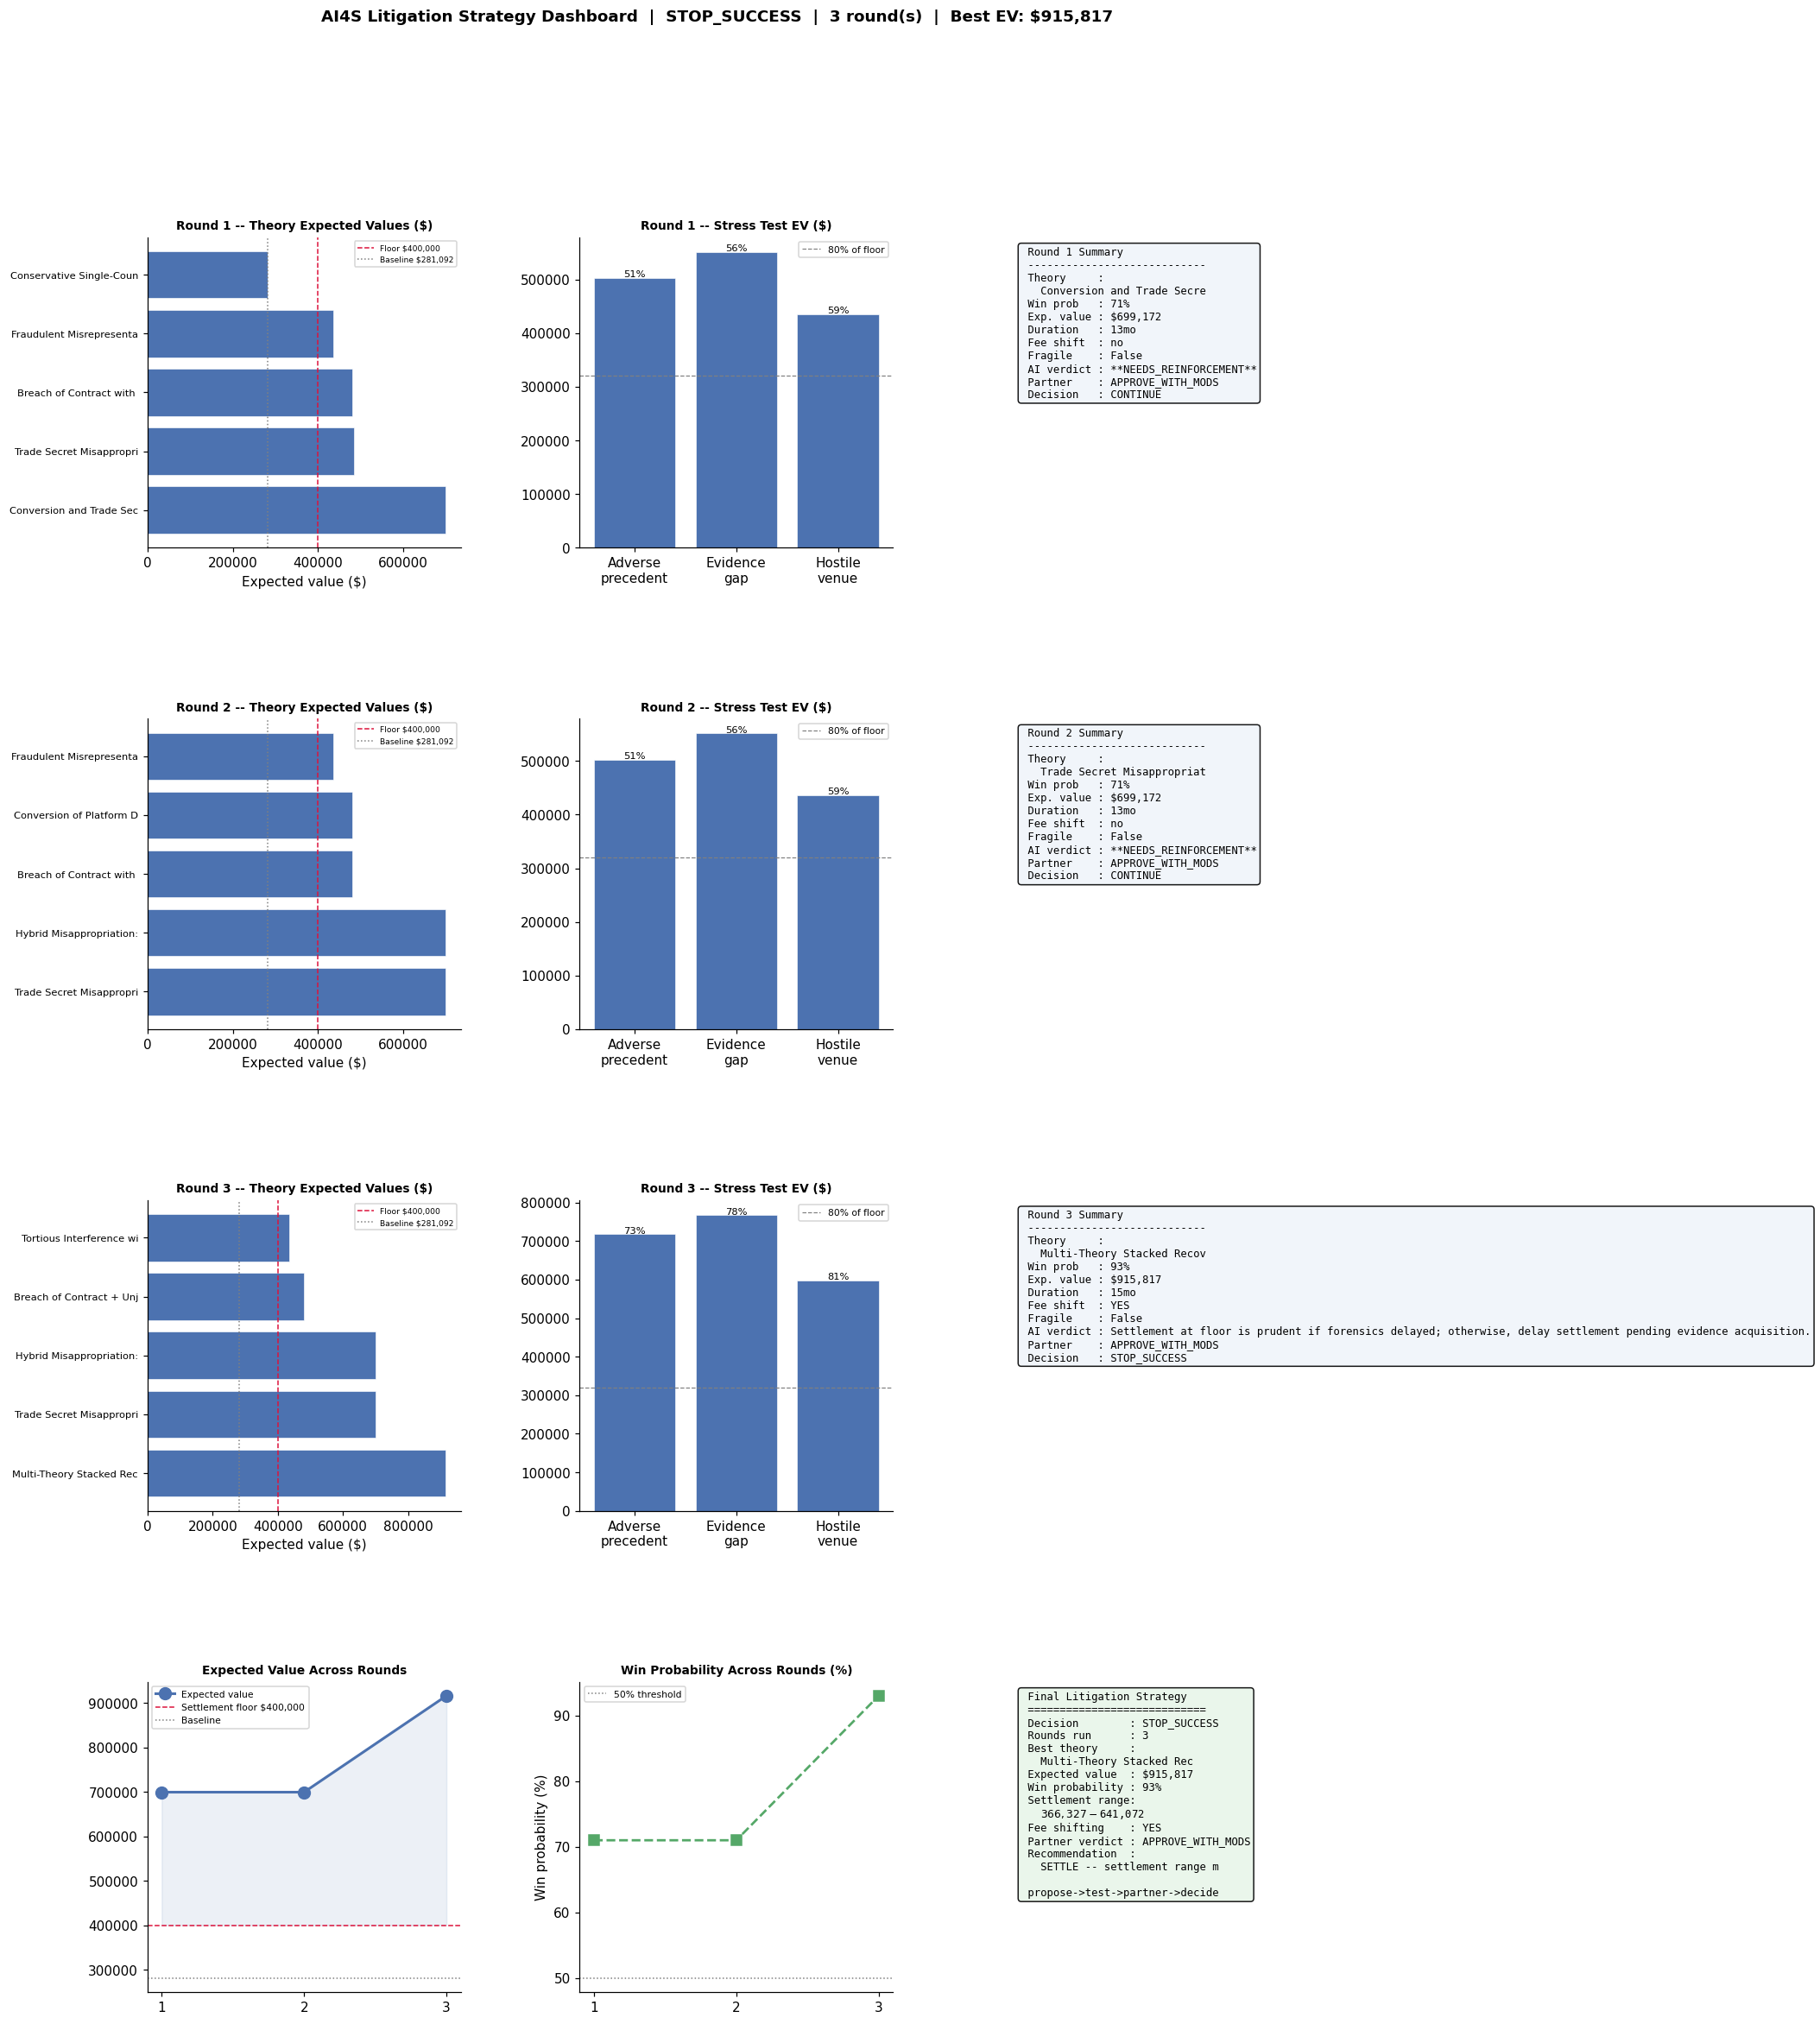


  CLIENT MEMO -- Meridian Analytics LLC

How to present to Meridian:
  > We have a strong, documented breach of contract case with $310K in unpaid fees backed by signed milestones and sign-off emails. We also have solid evidence that Quantum falsely told your prospective clients you were insolvent, causing two of them to walk. That's the foundation we can take to trial confidently, and it positions us well in settlement at $450–550K range.
  > The trade secret misappropriation claim—based on the two developers who left and Quantum's competing product—is valuable, but we need forensic analysis of Quantum's code and architecture to support damages claims above $200K. We're initiating that analysis now and will have answers within 6 weeks. That evidence could unlock significantly higher settlement leverage or trial damages; we won't know until we have it.
  > Our litigation budget is tight at $300K, so we're pursuing a disciplined two-phase strategy: Phase 1 is filing on the claims we ca

In [46]:
# CELL 9  FINAL LITIGATION REPORT DASHBOARD
# -----------------------------------------------------------------------

n_rounds = len(agent.round_results)
fig = plt.figure(figsize=(16, 6 * n_rounds + 6))
gs  = gridspec.GridSpec(n_rounds + 1, 3, figure=fig,
                        hspace=0.55, wspace=0.38)

for ri, r in enumerate(agent.round_results):
    rev = agent.attorney_reviews[ri] if ri < len(agent.attorney_reviews) else {}
    dec = agent.decision_log[ri]     if ri < len(agent.decision_log)     else {}

    # expected value bar chart
    ax1 = fig.add_subplot(gs[ri, 0])
    names = [s['theory']['name'][:24] for s in r.simulation_results]
    evs   = [max(s['ev'], 0)          for s in r.simulation_results]
    bc    = ['#4C72B0' if s['ethical'] else '#C44E52'
             for s in r.simulation_results]
    ax1.barh(names, evs, color=bc, edgecolor='white', linewidth=0.4)
    ax1.axvline(CASE['settlement_floor'], color='crimson',
                ls='--', lw=1, label=f'Floor ${CASE["settlement_floor"]:,}')
    ax1.axvline(baseline_sim.expected_value, color='grey',
                ls=':', lw=1, label=f'Baseline ${baseline_sim.expected_value:,.0f}')
    ax1.set_title(f'Round {r.cycle_num} -- Theory Expected Values ($)',
                  fontweight='bold', fontsize=9)
    ax1.set_xlabel('Expected value ($)')
    ax1.tick_params(axis='y', labelsize=7.5)
    ax1.legend(fontsize=6)

    # stress test
    ax2 = fig.add_subplot(gs[ri, 1])
    sc_labels = ['Adverse\nprecedent', 'Evidence\ngap', 'Hostile\nvenue']
    sc_evs    = [r.stress_results.get(k,{}).get('ev',0)
                 for k in ['adverse_precedent','evidence_gap','hostile_venue']]
    sc_wps    = [r.stress_results.get(k,{}).get('win_prob',0)
                 for k in ['adverse_precedent','evidence_gap','hostile_venue']]
    sc_colors = ['#4C72B0' if v > CASE['settlement_floor']*0.8 else '#C44E52'
                 for v in sc_evs]
    ax2.bar(sc_labels, sc_evs, color=sc_colors, edgecolor='white', linewidth=0.4)
    ax2.axhline(CASE['settlement_floor']*0.8, color='grey',
                ls='--', lw=0.8, label='80% of floor')
    for i, (ev, wp) in enumerate(zip(sc_evs, sc_wps)):
        ax2.text(i, ev + 2000, f'{wp:.0%}', ha='center', fontsize=7.5, color='black')
    ax2.set_title(f'Round {r.cycle_num} -- Stress Test EV ($)',
                  fontweight='bold', fontsize=9)
    ax2.legend(fontsize=7)

    # round summary
    ax3 = fig.add_subplot(gs[ri, 2])
    ax3.axis('off')
    sim      = r.best_sim
    fb_tag   = r.feedback_verdict.splitlines()[-1] if r.feedback_verdict else 'N/A'
    win_str  = f'{sim.win_probability:.0%}' if sim else 'N/A'
    ev_str   = f'${sim.expected_value:,.0f}' if sim else 'N/A'
    dur_str  = f'{sim.duration_est_months}mo' if sim else 'N/A'
    fee_str  = 'YES' if (sim and sim.fee_shifting) else 'no'
    txt = '\n'.join([
        f' Round {r.cycle_num} Summary',
        ' ' + '-'*28,
        f' Theory     :',
        f'   {r.best_theory.get("name","?")[:26]}',
        f' Win prob   : {win_str}',
        f' Exp. value : {ev_str}',
        f' Duration   : {dur_str}',
        f' Fee shift  : {fee_str}',
        f' Fragile    : {r.fragile}',
        f' AI verdict : {fb_tag}',
        f' Partner    : {rev.get("verdict","N/A")}',
        f' Decision   : {dec.get("decision","N/A")}',
    ])
    ax3.text(0.03, 0.97, txt, transform=ax3.transAxes,
             fontsize=8, va='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#f0f4fa', alpha=0.9))

# -- summary row -------------------------------------------------------
rounds = [r.cycle_num for r in agent.round_results]
evs    = [r.best_sim.expected_value if r.best_sim else 0
          for r in agent.round_results]
wps    = [r.best_sim.win_probability if r.best_sim else 0
          for r in agent.round_results]

axS1 = fig.add_subplot(gs[n_rounds, 0])
axS1.plot(rounds, evs, 'o-', color='#4C72B0', lw=2, ms=9, label='Expected value')
axS1.axhline(CASE['settlement_floor'], color='crimson', ls='--', lw=1,
             label=f'Settlement floor ${CASE["settlement_floor"]:,}')
axS1.axhline(baseline_sim.expected_value, color='grey', ls=':', lw=1,
             label='Baseline')
axS1.fill_between(rounds, evs, CASE['settlement_floor'],
                  alpha=0.10, color='#4C72B0')
axS1.set_title('Expected Value Across Rounds', fontweight='bold', fontsize=9)
axS1.set_xticks(rounds)
axS1.legend(fontsize=7)

axS2 = fig.add_subplot(gs[n_rounds, 1])
axS2.plot(rounds, [w*100 for w in wps], 's--', color='#55A868', lw=1.8, ms=8)
axS2.axhline(50, color='grey', ls=':', lw=1, label='50% threshold')
axS2.set_title('Win Probability Across Rounds (%)', fontweight='bold', fontsize=9)
axS2.set_xticks(rounds)
axS2.set_ylabel('Win probability (%)')
axS2.legend(fontsize=7)

axS3 = fig.add_subplot(gs[n_rounds, 2])
axS3.axis('off')
br   = best_result
bsim = br.best_sim
verdict_lines = [
    ' Final Litigation Strategy',
    ' ' + '='*28,
    f' Decision        : {agent.final_decision}',
    f' Rounds run      : {n_rounds}',
    f' Best theory     :',
    f'   {br.best_theory.get("name","?")[:24]}',
    f' Expected value  : ${bsim.expected_value:,.0f}' if bsim else '',
    f' Win probability : {bsim.win_probability:.0%}' if bsim else '',
    f' Settlement range:',
    f'   ${bsim.settlement_range[0]:,.0f} - ${bsim.settlement_range[1]:,.0f}' if bsim else '',
    f' Fee shifting    : {"YES" if (bsim and bsim.fee_shifting) else "no"}',
    f' Partner verdict : {best_review.get("verdict","N/A")}',
    f' Recommendation  :',
    f'   {br.settlement_rec[:28]}',
    '',
    ' propose->test->partner->decide',
]
axS3.text(0.03, 0.97, '\n'.join(verdict_lines),
          transform=axS3.transAxes, fontsize=8, va='top',
          fontfamily='monospace',
          bbox=dict(boxstyle='round', facecolor='#e8f5e9', alpha=0.9))

fig.suptitle(
    f'AI4S Litigation Strategy Dashboard  |  {agent.final_decision}'
    f'  |  {n_rounds} round(s)  |  Best EV: ${(bsim.expected_value if bsim else 0):,.0f}',
    fontsize=12, fontweight='bold'
)
plt.savefig('ai4s_litigation_dashboard.png', bbox_inches='tight', dpi=130)
plt.show()

print('\n' + '='*58)
print('  CLIENT MEMO -- Meridian Analytics LLC')
print('='*58)
if best_review.get('client_talking_points'):
    print('\nHow to present to Meridian:')
    for p in best_review['client_talking_points']:
        print(f'  > {p}')
if best_review.get('tactical_recommendations'):
    print('\nImmediate next steps:')
    for t in best_review['tactical_recommendations']:
        print(f'  >> {t}')
if best_review.get('modifications'):
    print('\nModifications required before filing:')
    for m in best_review['modifications']:
        print(f'  * {m}')

##3.CONCLUSIONS

---

This notebook set out to demonstrate that the AI4S discovery loop can operate
inside a domain governed not by physical laws but by professional rules — where
the evidence is a case file, the validation mechanism is a body of precedent, and
the human expert carries not just expertise but ethical and legal accountability
for every recommendation.

* What Was Built

The system built here does five things that a standard legal research tool does
not. It generates multiple legal theories simultaneously and evaluates them in
parallel rather than sequentially. It enforces an ethical gate before any theory
reaches quantitative analysis, so the system cannot produce an expected-value
number for an argument that violates the Model Rules. It anchors its win-probability
estimates to specific precedent outcomes rather than relying on Claude's general
legal knowledge. It stress-tests the best theory under adverse scenarios — hostile
precedent, evidence gaps, unfavourable venue — before any recommendation reaches
the attorney. And it treats Diana Reyes's required modifications as structured
feedback that propagates into the next generation of hypothesis formation, rather
than as a terminal override that simply stops the process.

* The Human Does Not Disappear

The most important design decision in this notebook is that Diana cannot be
bypassed. The `LitigationEvaluationAgent` will not issue a `STOP_SUCCESS` verdict
unless she has approved the recommendation. A rejected theory triggers another
cycle. Her modification requirements enter the failure context and shape what
Claude proposes next. This is not a system that generates recommendations and
presents them to a human for rubber-stamping. It is a system that treats the
attorney's judgment as a binding constraint on the search, not a post-processing
filter.

* What This Cannot Do

The system cannot replace the judgment that comes from sitting across a table from
the client, reading the opposing counsel, and knowing which judges in which
courtrooms respond to which arguments. It cannot account for the client's
emotional state, their appetite for a public fight, or the reputational
consequences of a proceeding that becomes visible. It cannot verify whether the
evidence it has been given is complete or whether facts material to the analysis
have been withheld or misremembered. These are the things that distinguish a
good lawyer from a good legal model, and they belong exclusively to the human.

* The Deeper Point

Litigation is a domain where the propose-test-learn loop has always operated —
it is what case strategy has always been. What AI4S adds is not a new way of
thinking about litigation but a new capacity to explore the search space more
systematically, to surface interactions between theories that a single attorney
working sequentially might miss, and to make the failure analysis explicit rather
than implicit. The loop proposed here — propose, test, advise, decide — is not
a replacement for legal judgment. It is a discipline that makes legal judgment
more informed.

